**Définition du Modèle avec TensorFlow/Keras**

In [ ]:
!pip install efficientnet==1.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.2 MB/s eta 0:00:00


**Importation des bibliothèques**

In [ ]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow import keras
# import the tensorflow.keras version of efficientnet
from efficientnet import tfkeras as efficientnet
import matplotlib.pyplot as plt

**Chargement du jeu de données**

In [ ]:
import sys
if 'google.colab' in sys.modules:
    !wget https://github.com/KiweeEu/transfer-learning-demo/raw/master/data/flowers.h5 -P ./data

flowers_data = h5py.File('./data/flowers.h5', 'r')
images_data = flowers_data['images'][:]
labels_data = flowers_data['labels'][:]


--2025-03-01 11:25:00--  https://github.com/KiweeEu/transfer-learning-demo/raw/master/data/flowers.h5
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/KiweeEu/transfer-learning-demo/master/data/flowers.h5 [following]
--2025-03-01 11:25:00--  https://raw.githubusercontent.com/KiweeEu/transfer-learning-demo/master/data/flowers.h5
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10324178 (9.8M) [application/octet-stream]
Saving to: ‘./data/flowers.h5’

flowers.h5          100%[===================>]   9.85M  --.-KB/s    in 0.05s   

2025-03-01 11:25:01 (216 MB/s) - ‘./data/flowers.h5’ saved [10324178/

Affichage des caractéristiques des données

In [ ]:
print(f'Images data shape: {images_data.shape}')
print(f'Labels data shape: {labels_data.shape}')
print(f'Images data min: {np.min(images_data)}, max: {np.max(images_data)}')
print(f'Images data type: {images_data.dtype}')
print(f'Labels data type: {labels_data.dtype}')
print(f'Unique labels: {np.unique(labels_data)}')
print(f'Number of unique labels: {len(np.unique(labels_data))}')


Images data shape: (210, 128, 128, 3)
Labels data shape: (210,)
Images data min: 0, max: 255
Images data type: uint8
Labels data type: uint8
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of unique labels: 10


Visualisation des données

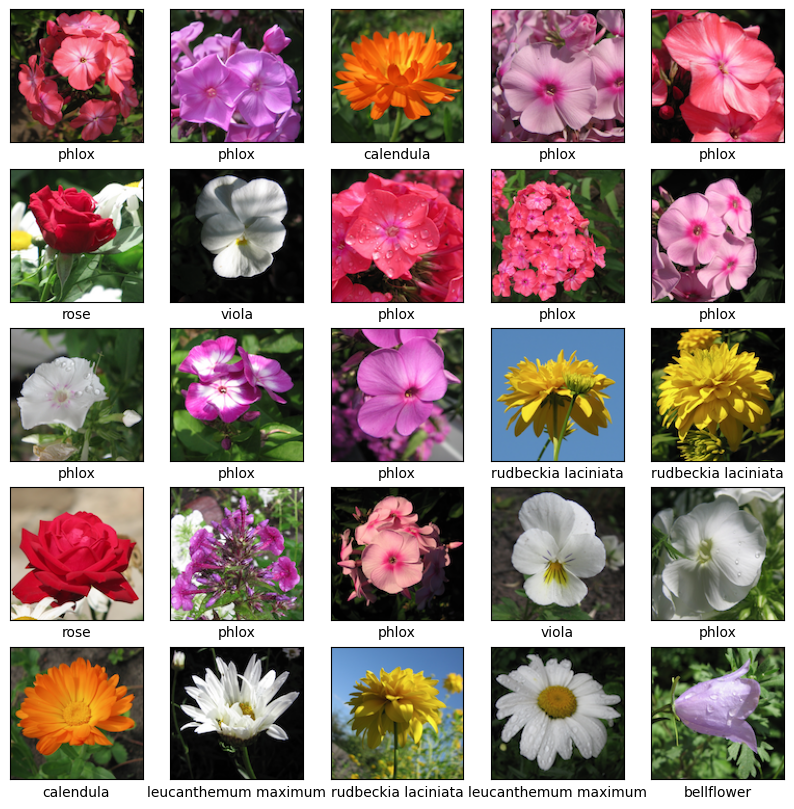

In [ ]:

# Names of flower species are just for visualisation
flower_names = [
 'phlox','rose','calendula','iris','leucanthemum maximum',
    'bellflower','viola','rudbeckia laciniata','peony','aquilegia'
]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(images_data[i])
    plt.xlabel(flower_names[labels_data[i]])
plt.show()

Affichage du nombre d'images par classe

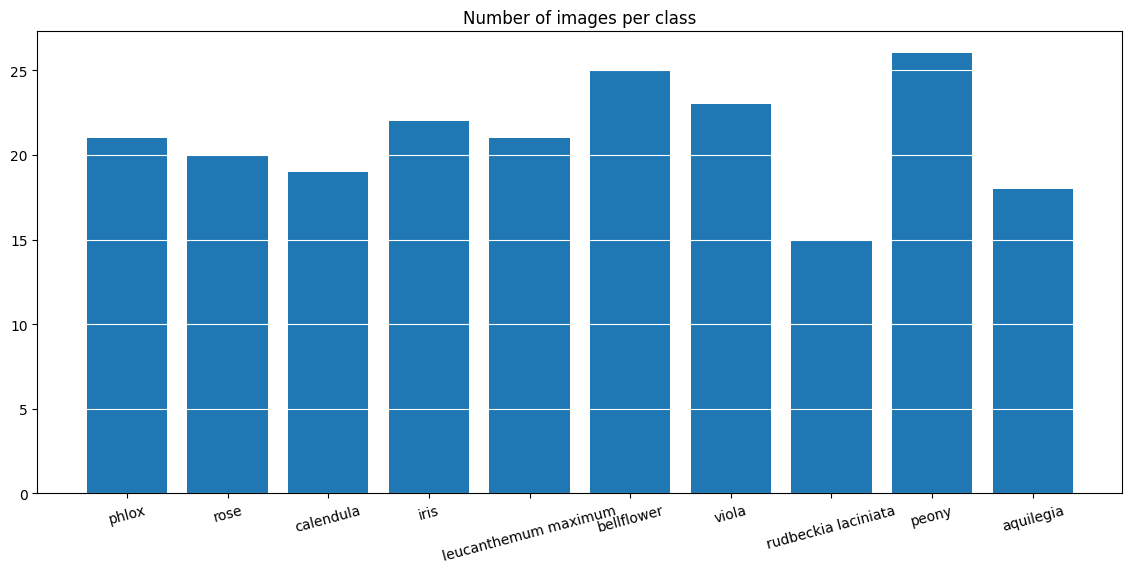

In [ ]:

unique, counts = np.unique(labels_data, return_counts=True)
ticks = np.arange(len(counts))
plt.figure(figsize=(14,6))
plt.grid(color='w', axis='y')
plt.bar(ticks, counts)
plt.xticks(ticks, flower_names, rotation=15)
plt.title('Number of images per class')
plt.show()

Préparation des données

In [ ]:
# Set a seed for reproducibility
seed = 1
def shuffle(a, b, seed=None):
    rand = np.random.RandomState(seed)
    p = rand.permutation(a.shape[0])
    return a[p], b[p]

x_data, y_data = shuffle(images_data, labels_data, seed=seed)

split_idx = int(0.5*x_data.shape[0])
x_train, y_train = x_data[:split_idx], y_data[:split_idx]
x_val, y_val = x_data[split_idx:], y_data[split_idx:]


train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    data_format='channels_last',
    preprocessing_function=efficientnet.preprocess_input
)

val_datagen = keras.preprocessing.image.ImageDataGenerator(
    data_format='channels_last',
    preprocessing_function=efficientnet.preprocess_input
)



Création des itérateurs de batch

In [ ]:
train_iterator = train_datagen.flow(x_train, y_train, batch_size=35)
val_iterator = val_datagen.flow(x_val, y_val, batch_size=105)

Création du modèle

In [ ]:
def get_model(input_shape, num_classes):
    base_model = efficientnet.EfficientNetB4(
        weights='noisy-student',
        pooling='avg',
        include_top=False,
        input_shape=input_shape
    )
      # "Freeze" the base_model layers so that we don't backpropagate through them.
    # This effectively makes base_model a feature extractor.
    for layer in base_model.layers:
        layer.trainable = False
        # Create our own fully-conected top layer with num_classes outputs that takes base_model.output as an input.
    # We use the 'softmax' activation for computing class probabilities.
    x = base_model.output
    predictions = keras.layers.Dense(num_classes, activation='softmax')(x)

    # the Model class packages our architecture into one object
    model = keras.models.Model(inputs=base_model.input, outputs=predictions)
    return model


Compilation et exécution du modèle

In [ ]:
model = get_model(input_shape=(128, 128, 3), num_classes=10)
model.compile(
    optimizer='adam',
    loss=keras.losses.sparse_categorical_crossentropy,
    metrics=['accuracy']
)


71678424/71678424 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Entraînement**

In [ ]:
model.fit(train_iterator, epochs=30)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.1631 - loss: 2.3380
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.2798 - loss: 2.0875
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.3048 - loss: 1.8955
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.3881 - loss: 1.7984
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.4000 - loss: 1.8041
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6071 - loss: 1.4869
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5798 - loss: 1.4150
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.6667 - loss: 1.3218
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.6357 - loss: 1.2986
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7143 - loss: 1.2119
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.7429 - loss: 1.1350
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.7833 - loss: 1.0151
Epoch 13/30
3/3 ━━━━━━━━

**Évaluation du modèle**

In [ ]:

val_loss, val_acc = model.evaluate(val_iterator)
print(f'Validation loss: {round(val_loss, 4)}\nValidation accuracy: {round(val_acc*100, 4)}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.8667 - loss: 0.6203
Validation loss: 0.6203
Validation accuracy: 86.6667%
